# Notebook 1 : Exploration et clustering

## 1 : Import du dataset et EDA

Cette première étape a pour but de prendre connaissance du jeu de données fourni par *CurelyticsIA* avant toute transformation. On y vérifie la **structure des dossiers**, le **nombre d'images disponibles**, leur **résolution** et **leur mode de couleur**, ainsi que la **répartition** entre images labellisées et non labellisées.

Ces observations conditionnent les choix de preprocessing des étapes suivantes, notamment la compatibilité avec le modèle ResNet pré-entraîné.

### 1.1. Imports

Commençons par importer les packages nécessaires.

In [1]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

RANDOM_STATE = 42

### 1.2. Structure du dataset

On explore l'arborescence du dossier extrait du zip afin d'identifier comment les images sont organisées sur le disque.

Cette inspection permet de confirmer ou d'ajuster les hypothèses de structure avant d'écrire le code de comptage et de chargement des images.

In [2]:
DATA_DIR = Path("../data/mri_dataset_brain_cancer_oc")

assert DATA_DIR.exists(), f"Dossier introuvable : {DATA_DIR}, vérifie le chemin d'extraction du zip"

def lister_structure(root: Path, max_depth: int = 3):
    for path in sorted(root.rglob("*")):
        depth = len(path.relative_to(root).parts)
        if depth > max_depth:
            continue
        prefix = "  " * (depth - 1)
        marker = "/" if path.is_dir() else ""
        print(f"{prefix}{path.name}{marker}")

lister_structure(DATA_DIR)

mri_dataset_brain_cancer_oc/
  avec_labels/
    cancer/
    normal/
  Jeu de Données d'Images Cérébrales pour la Détection de Tumeurs.txt
  sans_label/
    001b158a-7af8-451e-bf31-3a9116265f3a.jpg
    00366e8d-5520-4d3c-a70b-91a7eec1f521.jpg
    00455a62-f79f-4072-9a23-4951e759acdc.jpg
    004ce5f5-ca6b-490f-9b2f-c322c152e2ee.jpg
    005d9a37-8894-4eb5-8367-1015d4a43638.jpg
    009e9d31-9f37-4d97-a941-81501294c403.jpg
    009eac4a-c951-4da9-852a-b32e9ce20c6e.jpg
    00e9e198-79de-47ab-9f4e-7b76152324bb.jpg
    01274f5e-3064-4efd-af4b-38e164188c31.jpg
    01717fbf-4bcf-475a-a718-361ed07d2854.jpg
    01d1f0ed-5070-45a8-ad26-f8a95ebec98d.jpg
    01d4471e-7c83-4335-ab49-c650d0da1dea.jpg
    01e09766-fcd9-4df0-82f7-265f9ffecdf6.jpg
    01f4b8d2-56ed-4d82-ad41-6864de091425.jpg
    01fa1329-7524-49f5-8f11-bb9d8717a3fe.jpg
    0208c07c-bc4b-4741-ad0f-d5beeb18cc52.jpg
    02af8a8e-3c79-4a3c-8412-52f483eb9411.jpg
    02d2c771-7bf5-4771-972c-7f123088b7b0.jpg
    0303753e-919b-4947-8e55-4fc922bfbe

le dataset est organisé en deux grandes branches, `avec_labels/` contenant deux sous-dossiers `cancer` et `normal` correspondant aux annotations des radiologues, et `sans_label/` regroupant les images non annotées à plat, sans sous-catégorie.

Cette organisation confirme l'hypothèse de départ et valide l'usage du nom de dossier parent comme proxy de label pour la suite de l'analyse.

### 1.3. Recensement des images et formats

On liste ici l'ensemble des fichiers images du dataset, tous sous-dossiers confondus, et on relève les extensions de fichiers rencontrées.

Cette étape sert de vérification de cohérence : le total obtenu est comparé au volume annoncé dans la documentation du dataset.

In [3]:
extensions_valides = {".png", ".jpg", ".jpeg"}
fichiers_images = [p for p in DATA_DIR.rglob("*") if p.suffix.lower() in extensions_valides]

print(f"Nombre total d'images trouvées : {len(fichiers_images)}")

extensions_trouvees = Counter(p.suffix.lower() for p in fichiers_images)
print(f"Formats rencontrés : {dict(extensions_trouvees)}")

Nombre total d'images trouvées : 1506
Formats rencontrés : {'.jpg': 1506}


le dataset contient 1506 images, toutes au format `.jpg`, un format unique. C'est une bonne nouvelle pour la suite : pas besoin de gérer une conversion de format inter-fichiers avant le preprocessing.

Le total de 1506 est légèrement supérieur aux 1500 images annoncées dans la documentation du dataset (écart de 6 images), à noter comme observation mineure sans impact sur la suite.

### 1.4. Résolution et canaux de couleur (échantillon)

On ouvre un échantillon d'images pour en extraire la largeur, la hauteur et le mode de couleur (niveaux de gris ou RGB).

L'objectif est de savoir si les images sont homogènes ou s'il faudra prévoir un redimensionnement et une conversion de canaux avant de les passer dans un modèle pré-entraîné.

In [4]:
def inspecter_image(path: Path) -> dict:
    with Image.open(path) as img:
        return {
            "chemin": str(path.relative_to(DATA_DIR)),
            "largeur": img.width,
            "hauteur": img.height,
            "mode": img.mode,
        }

echantillon = fichiers_images if len(fichiers_images) <= 200 else np.random.choice(
    fichiers_images, size=200, replace=False
)

infos = pd.DataFrame([inspecter_image(p) for p in echantillon])

print("Résolutions rencontrées :")
print(infos.groupby(["largeur", "hauteur"]).size())

print("\nModes de couleur rencontrés (canaux) :")
print(infos["mode"].value_counts())

Résolutions rencontrées :
largeur  hauteur
512      512        200
dtype: int64

Modes de couleur rencontrés (canaux) :
mode
RGB    200
Name: count, dtype: int64


Sur l'échantillon de 200 images inspectées, la résolution est parfaitement homogène à 512×512 pixels, conforme à la documentation du dataset.

Le mode de couleur est également homogène, RGB sur les 200 images, aucune image en niveaux de gris.

C'est une bonne nouvelle pour l'étape 2 : pas de redimensionnement hétérogène ni de conversion de canaux à gérer avant l'extraction de features avec ResNet, qui attend justement des images RGB.

### 1.5. Comptage des labels

La structure observée distingue trois sous-ensembles : `avec_labels/cancer/`, `avec_labels/normal/` pour les images annotées par les radiologues, et `sans_label/` pour le reste.

On compte ici le nombre d'images dans chaque sous-dossier afin de vérifier la répartition entre données fortement labellisées et données à labelliser par la suite.

In [5]:
def compter_par_dossier_parent(fichiers: list[Path]) -> Counter:
    return Counter(p.parent.name for p in fichiers)

comptage = compter_par_dossier_parent(fichiers_images)
print("Comptage d'images par dossier parent (proxy du label) :")
for dossier, n in comptage.items():
    print(f"  {dossier} : {n}")

Comptage d'images par dossier parent (proxy du label) :
  cancer : 50
  normal : 50
  sans_label : 1406


le jeu labellisé compte 100 images, réparties de façon parfaitement équilibrée entre `cancer` (50) et `normal` (50), un point favorable puisqu'**il évite un biais de classe** sur le jeu fortement labellisé qui servira au calcul du score ARI.

Le jeu non labellisé compte 1406 images (93 % du dataset total), qui seront labellisées faiblement par clustering aux étapes suivantes.

### 1.6. Exemples visuels, un échantillon équilibré par label

Un tirage purement aléatoire sur l'ensemble du dataset donnerait quasi uniquement des images non labellisées, puisqu'elles représentent la grande majorité des 1506 images.

On force donc ici un échantillon équilibré, avec des exemples issus de chaque catégorie (`cancer`, `normal`, `sans_label`), pour avoir un aperçu visuel représentatif des trois populations.

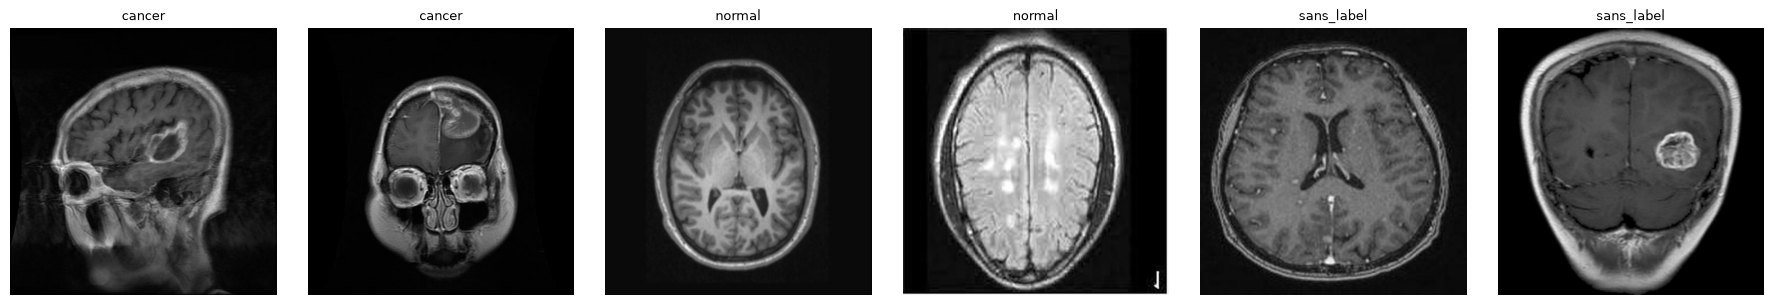

In [6]:
# On force un mix : quelques cancer, quelques normal, quelques sans_label
fichiers_cancer = [p for p in fichiers_images if p.parent.name == "cancer"]
fichiers_normal = [p for p in fichiers_images if p.parent.name == "normal"]
fichiers_sans_label = [p for p in fichiers_images if p.parent.name == "sans_label"]

n_par_groupe = 2
exemples = (
    list(np.random.choice(fichiers_cancer, size=min(n_par_groupe, len(fichiers_cancer)), replace=False))
    + list(np.random.choice(fichiers_normal, size=min(n_par_groupe, len(fichiers_normal)), replace=False))
    + list(np.random.choice(fichiers_sans_label, size=min(n_par_groupe, len(fichiers_sans_label)), replace=False))
)

fig, axes = plt.subplots(1, len(exemples), figsize=(3 * len(exemples), 3))
for ax, chemin in zip(axes, exemples):
    with Image.open(chemin) as img:
        ax.imshow(img, cmap="gray" if img.mode == "L" else None)
    ax.set_title(chemin.parent.name, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2 : Preprocessing

Cette étape prépare les images pour l'extraction de features avec un modèle ResNet pré-entraîné.

On vérifie d'abord l'absence d'outliers sur l'ensemble du dataset (fichiers corrompus, tailles ou modes de couleur hétérogènes non détectés dans l'échantillon précédent), puis on définit le pipeline de redimensionnement et de normalisation attendu par ResNet.

### 2.1. Nettoyage et détection d'outliers sur l'ensemble du dataset

L'EDA portait sur un échantillon de 200 images. On passe ici en revue les 1506 images pour s'assurer qu'aucun fichier n'est corrompu, illisible, ou de taille/mode différent de la norme observée (512×512, RGB), avant de lancer un preprocessing en masse.

In [7]:
def verifier_image(path: Path) -> dict:
    """Tente d'ouvrir l'image et retourne ses caractéristiques, ou une erreur si corrompue."""
    try:
        with Image.open(path) as img:
            img.verify()  # vérifie l'intégrité du fichier sans le charger entièrement
        with Image.open(path) as img:  # verify() invalide l'objet, on rouvre pour lire les attributs
            return {
                "chemin": str(path.relative_to(DATA_DIR)),
                "largeur": img.width,
                "hauteur": img.height,
                "mode": img.mode,
                "corrompue": False,
                "erreur": None,
            }
    except Exception as e:
        return {
            "chemin": str(path.relative_to(DATA_DIR)),
            "largeur": None,
            "hauteur": None,
            "mode": None,
            "corrompue": True,
            "erreur": str(e),
        }

# Vérification sur l'ensemble du dataset (peut prendre quelques minutes selon la machine)
verification_complete = pd.DataFrame([verifier_image(p) for p in fichiers_images])

n_corrompues = verification_complete["corrompue"].sum()
print(f"Images corrompues détectées : {n_corrompues}")

if n_corrompues > 0:
    print(verification_complete[verification_complete["corrompue"]])

resolutions_hors_norme = verification_complete[
    (verification_complete["corrompue"] == False)
    & ((verification_complete["largeur"] != 512) | (verification_complete["hauteur"] != 512))
]
print(f"\nImages avec une résolution différente de 512x512 : {len(resolutions_hors_norme)}")

modes_hors_norme = verification_complete[
    (verification_complete["corrompue"] == False) & (verification_complete["mode"] != "RGB")
]
print(f"Images avec un mode de couleur différent de RGB : {len(modes_hors_norme)}")

Images corrompues détectées : 0

Images avec une résolution différente de 512x512 : 0
Images avec un mode de couleur différent de RGB : 0


**Aucune anomalie détectée sur l'ensemble des 1506 images**.

Aucun fichier corrompu, aucune résolution différente de 512×512, aucun mode de couleur différent de RGB.

L'homogénéité observée sur l'échantillon de 200 images à l'étape précédente se confirme donc sur la totalité du dataset, **le jeu de données ne nécessite pas de nettoyage préalable**.

### 2.2. Pipeline de redimensionnement et normalisation

ResNet pré-entraîné sur ImageNet attend des images en 224×224 pixels, avec une normalisation spécifique (moyenne et écart-type calculés sur ImageNet).

On définit ici les transformations correspondantes avec `torchvision.transforms`, qui seront réutilisées telles quelles à l'étape d'extraction de features.

In [8]:
from torchvision import transforms

# Valeurs standard ImageNet, attendues par les modèles ResNet pré-entraînés
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

preprocessing_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Test rapide sur une image pour valider le pipeline
image_test = Image.open(fichiers_images[0]).convert("RGB")
tenseur_test = preprocessing_resnet(image_test)
print(f"Forme du tenseur après preprocessing : {tenseur_test.shape}")
print(f"Valeurs min/max après normalisation : {tenseur_test.min():.3f} / {tenseur_test.max():.3f}")

Forme du tenseur après preprocessing : torch.Size([3, 224, 224])
Valeurs min/max après normalisation : -2.118 / 2.274


Le pipeline de redimensionnement et normalisation fonctionne comme attendu, le tenseur obtenu a la forme `[3, 224, 224]`, conforme au format d'entrée de ResNet (3 canaux RGB, 224×224 pixels).

Les valeurs normalisées s'étendent de -2,118 à 2,274, une plage cohérente avec une normalisation ImageNet standard (les valeurs négatives sont normales, elles correspondent aux pixels sous la moyenne du dataset ImageNet).

**Le pipeline est validé** et prêt à être appliqué sur l'ensemble des images à l'étape d'extraction de features.

## 3. Features et réduction de dimension

Cette section a pour but de transformer chaque image, une grille de 224x224x3 pixels difficile à comparer directement, en un vecteur numérique compact et exploitable : l'**embedding**.

On s'appuie pour cela sur un réseau **ResNet18 pré-entraîné sur ImageNet**, utilisé uniquement comme extracteur de features (aucun entraînement ici, les poids restent gelés). Les embeddings obtenus seront ensuite réduits en dimension (PCA puis t-SNE) pour être visualisés et préparer le clustering de l'étape suivante.

### 3.1. Imports

On importe ici les briques nécessaires à l'extraction de features : `torch` pour la manipulation des tenseurs et du modèle, et `resnet18` / `ResNet18_Weights` depuis `torchvision.models` pour charger l'architecture et ses poids pré-entraînés sur ImageNet.

In [9]:
# Imports

import torch
from torchvision.models import resnet18, ResNet18_Weights

### 3.2. Sélection du matériel de calcul

PyTorch peut exécuter les calculs sur GPU (`cuda`) si disponible, sinon sur CPU. On détecte automatiquement le matériel disponible : l'extraction sera plus rapide sur GPU, mais fonctionne aussi sur CPU pour 1506 images.

In [10]:
# Sélection du matériel de calcul

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Exécution sur le {device}")

Exécution sur le cpu


### 3.3. Chargement du ResNet18 et préparation de l'extracteur de features

On charge un ResNet18 pré-entraîné sur ImageNet, puis on l'adapte pour en faire un pur extracteur de features :

- **Gel des couches** : chaque paramètre du modèle voit son `requires_grad` mis à `False`, aucun poids ne sera modifié, on utilise le réseau tel quel.
- **Retrait de la dernière couche** : la couche `fc` originale de ResNet transforme le vecteur final en scores pour les 1000 classes ImageNet, ce qui ne nous intéresse pas. En ne gardant que `list(model.children())[:-1]`, on récupère le modèle jusqu'à l'avant-dernière couche, celle qui produit l'embedding.
- **Mode évaluation** (`eval()`) : désactive les comportements spécifiques à l'entraînement (comme le dropout), pour un comportement stable et déterministe en inférence.

In [11]:
# Chargement du ResNet18 pré-entraîné sur ImageNet
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Gel des couches : aucun poids ne sera mis à jour
for param in model.parameters():
    param.requires_grad = False

# On retire la dernière couche (fc, classification 1000 classes) pour ne garder que l'embedding en sortie de l'avant-dernière couche
feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()  # mode évaluation : désactive dropout/batchnorm en mode "train"

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (

`feature_extractor` est maintenant un ResNet18 gelé, sans sa couche de classification finale : il prend une image en entrée et renvoie un vecteur d'embedding en sortie, au lieu d'une prédiction de classe.

### 3.4. Dataset et DataLoader pour le chargement par lots

Pour appliquer le pipeline de preprocessing (`preprocessing_resnet`, défini en 2.2) à l'ensemble des 1506 images de façon efficace, on définit un `Dataset` PyTorch : une classe qui sait, pour un index donné, charger l'image correspondante et lui appliquer la transformation.

Le `DataLoader` s'appuie ensuite sur ce `Dataset` pour fournir les images par lots (`batch_size`) au modèle, plutôt qu'une par une, ce qui est plus rapide. `shuffle=False` est important ici : on garde l'ordre des images pour pouvoir associer chaque embedding produit à son image d'origine.

In [12]:
from torch.utils.data import Dataset, DataLoader

class MRIDataset(Dataset):
    """Charge une image depuis son chemin et applique le preprocessing ResNet."""
    def __init__(self, fichiers, transform):
        self.fichiers = fichiers
        self.transform = transform

    def __len__(self):
        return len(self.fichiers)

    def __getitem__(self, idx):
        path = self.fichiers[idx]
        image = Image.open(path).convert("RGB")
        tensor = self.transform(image)
        return tensor, str(path.relative_to(DATA_DIR))

dataset = MRIDataset(fichiers_images, preprocessing_resnet)
dataloader = DataLoader(dataset, batch_size=64, shuffle=False)

Le `dataloader` est prêt : il fournira les 1506 images sous forme de lots de 64 tenseurs `[3, 224, 224]`, déjà redimensionnés et normalisés, accompagnés du chemin relatif de chaque image.

### 3.5. Extraction des embeddings

On fait maintenant passer toutes les images dans `feature_extractor`, lot par lot, sous `torch.no_grad()` pour éviter tout calcul de gradient inutile (on ne fait qu'inférer, pas d'entraînement).

La sortie du modèle pour chaque image a la forme `[512, 1, 1]` (à cause de l'average pooling final de ResNet18) ; on l'aplatit en un vecteur `[512]`. Les embeddings de toutes les images sont concaténés dans un tableau numpy, avec la liste des chemins associés pour garder la correspondance.

In [13]:
# Extraction des embeddings pour toutes les images
embeddings = []
image_paths = []  # pour garder la correspondance ligne <-> image

with torch.no_grad():  # pas de calcul de gradient, on ne fait qu'inférer
    for img_tensor, path in dataloader:
        img_tensor = img_tensor.to(device)
        output = feature_extractor(img_tensor)  # shape [batch, 512, 1, 1]
        output = output.squeeze(-1).squeeze(-1)  # shape [batch, 512]
        embeddings.append(output.cpu().numpy())
        image_paths.extend(path)

embeddings = np.concatenate(embeddings, axis=0)
print(embeddings.shape)  # attendu : (1506, 512)

(1506, 512)


### 3.6. Réduction de dimension

Les embeddings extraits par ResNet18 comptent 512 dimensions par image, impossibles à visualiser ou à interpréter directement.

Cette section applique une réduction de dimension en deux temps pour obtenir une représentation en 2D exploitable visuellement, et qui servira de base au clustering de l'étape suivante :
- une standardisation des features
- une PCA intermédiaire (512 → 50 dimensions)
- puis un t-SNE final (50 → 2 dimensions).

In [14]:
# Import des packages utiles à la réduction de dimension
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

#### 3.6.1. Standardisation des embeddings

PCA et t-SNE sont sensibles à l'échelle des variables : une dimension aux valeurs plus grandes dominerait artificiellement les autres dans le calcul des distances.

On standardise donc chaque dimension de l'embedding pour la ramener à une moyenne de 0 et un écart-type de 1, avant toute réduction de dimension.

In [15]:
# Standardisation des embeddings : moyenne 0, écart-type 1 sur chaque dimension
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings)

#### 3.6.2. Réduction intermédiaire par PCA

Une première réduction par PCA ramène les 512 dimensions à 50, en conservant l'essentiel de la variance du jeu de données.

Cette étape sert à réduire le bruit et la charge de calcul avant t-SNE, ce n'est pas encore la projection finale utilisée pour la visualisation.

In [16]:
# Réduction 1 : PCA, de 512 vers 50 dimensions
# Objectif : réduire le bruit et la charge de calcul avant t-SNE, pas encore la visualisation finale
pca = PCA(n_components=50)
embeddings_pca = pca.fit_transform(embeddings_scaled)

print(f"Variance expliquée conservée par la PCA : {pca.explained_variance_ratio_.sum():.2%}")

Variance expliquée conservée par la PCA : 71.58%


La PCA à 50 composantes conserve **71,57 % de la variance** des embeddings originaux.

C'est un compromis raisonnable : on perd une partie de l'information la moins significative, mais l'essentiel du signal utile à la distinction entre images est préservé pour l'étape suivante.

#### 3.6.3. Projection finale par t-SNE

t-SNE prend le relais pour projeter les 50 dimensions en 2 dimensions, en cherchant à préserver les proximités locales entre images similaires : deux images proches en 50D restent proches en 2D.

La perplexité est laissée à sa valeur par défaut (30), sans réglage fin, conformément au périmètre de la tâche.

In [17]:
# Réduction 2 : t-SNE, de 50 vers 2 dimensions, pour visualisation
tsne = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=30, random_state=RANDOM_STATE)
embeddings_tsne = tsne.fit_transform(embeddings_pca)

#### 3.6.4. Visualisation du nuage de points

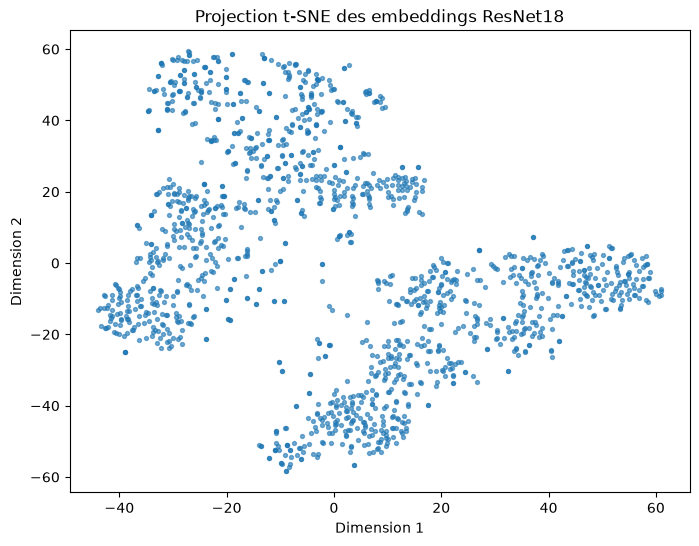

In [18]:
# Visualisation du nuage de points en 2D
plt.figure(figsize=(8, 6))
plt.scatter(embeddings_tsne[:, 0], embeddings_tsne[:, 1], s=8, alpha=0.6)
plt.title("Projection t-SNE des embeddings ResNet18")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

Le nuage de points obtenu fait apparaître **plusieurs regroupements visuellement distincts**, avec quelques zones de recouvrement ou de transition entre poches.

C'est un signal positif : les embeddings ResNet18 semblent porter une structure exploitable, cohérente avec l'existence de sous-groupes dans les images, à confirmer par un clustering formel (K-Means, DBSCAN) à l'étape suivante.

Aucun résultat parfaitement séparé n'est attendu à ce stade, une lecture qualitative suffit.

## 4. Clustering

### 4.1. Application de K-Means et DBSCAN

On applique ici les deux méthodes de clustering sur la projection t-SNE en 2D obtenue à l'étape 3.6, avec pour objectif d'identifier des regroupements d'images sans utiliser les labels forts.

K-Means est configuré avec `n_clusters=2`, en cohérence avec le nombre de classes du jeu labellisé (cancer / normal). DBSCAN ne reçoit pas de contrainte sur le nombre de clusters : ses deux hyperparamètres, `eps` (rayon de voisinage) et `min_samples` (nombre minimum de voisins pour former une zone dense), sont fixés à des valeurs de départ raisonnables au vu de l'échelle des axes t-SNE, sans réglage fin.

Les résultats des deux méthodes sont affichés côte à côte pour permettre une première comparaison visuelle, avant l'évaluation quantitative par score ARI à l'étape suivante.

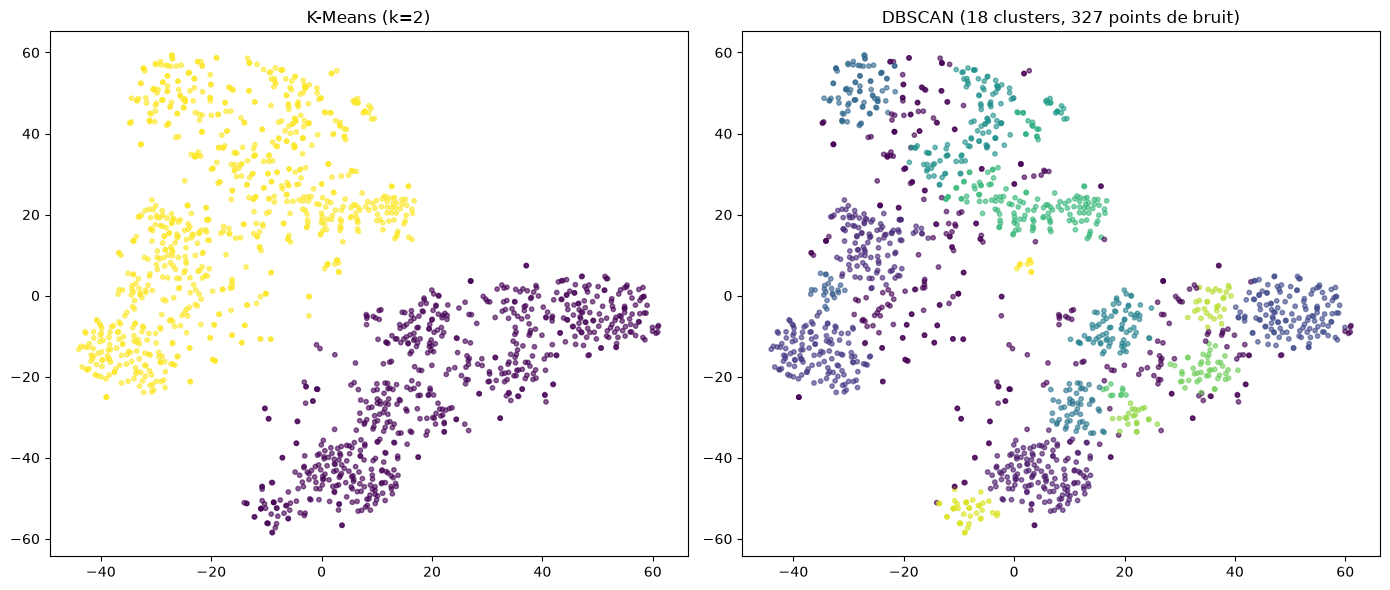

In [19]:
from sklearn.cluster import KMeans, DBSCAN

# K-Means
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
labels_kmeans = kmeans.fit_predict(embeddings_tsne)

# DBSCAN
dbscan = DBSCAN(eps=3, min_samples=10)
labels_dbscan = dbscan.fit_predict(embeddings_tsne)

# Visualisation côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(embeddings_tsne[:, 0], embeddings_tsne[:, 1],
                 c=labels_kmeans, cmap='viridis', s=10, alpha=0.6)
axes[0].set_title("K-Means (k=2)")

axes[1].scatter(embeddings_tsne[:, 0], embeddings_tsne[:, 1],
                 c=labels_dbscan, cmap='viridis', s=10, alpha=0.6)
n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1)
axes[1].set_title(f"DBSCAN ({n_clusters_dbscan} clusters, {n_noise} points de bruit)")

plt.tight_layout()
plt.show()

**K-Means** sépare nettement le nuage en deux grandes zones, cohérentes avec la séparation visuelle observée à l'étape 3.6.4 entre le groupe haut et le groupe bas du plan t-SNE.

**DBSCAN** produit un résultat très différent : environ 20 clusters et plus de 250 points classés comme bruit. Ce n'est pas un dysfonctionnement, c'est cohérent avec son fonctionnement par densité locale : il détecte les sous-amas à l'intérieur de chacune des deux grandes zones plutôt que de les regrouper en deux blocs, contrairement à K-Means qui est contraint à `k=2`.

À ce stade, aucune des deux visualisations ne permet de dire laquelle des deux méthodes colle le mieux à la réalité cancer/normal, cette comparaison purement visuelle ne suffit pas à trancher. C'est l'objet du calcul du score ARI sur les labels forts à l'étape suivante.

### 4.2. Évaluation par score ARI

Le score ARI (Adjusted Rand Index) mesure l'accord entre un clustering et un vrai découpage en classes, en comparant l'ensemble des paires d'images : deux images sont-elles regroupées ensemble ou séparées de la même façon dans les deux découpages ? Contrairement à un simple taux d'accord, l'ARI est corrigé pour tenir compte du hasard : un clustering aléatoire obtient un score proche de 0, un accord parfait donne 1.

On calcule ici l'ARI entre les vrais labels forts (`cancer` / `normal`, connus pour 100 images) et les labels prédits par K-Means d'une part, par DBSCAN d'autre part, sur ce même sous-ensemble de 100 images.

In [20]:
from pathlib import Path
from sklearn.metrics import adjusted_rand_score

# Repérage des 100 images fortement labellisées via le nom du dossier parent direct,
# robuste au nom du dossier racine du dataset et au séparateur de chemin
cancer_list = []
normal_list = []

for i, path in enumerate(image_paths):
    dossier_parent = Path(path).parent.name
    if dossier_parent == 'cancer':
        cancer_list.append(i)
    elif dossier_parent == 'normal':
        normal_list.append(i)

print(f"Il y a {len(cancer_list)} images annotées comme 'cancer'")
print(f"Il y a {len(normal_list)} images annotées comme 'normal'")

# ARI : comparaison des labels prédits aux vrais labels, sur les 100 images fortes uniquement
indices_forts = cancer_list + normal_list
vrais_labels = [1] * len(cancer_list) + [0] * len(normal_list)

kmeans_forts = [labels_kmeans[i] for i in indices_forts]
dbscan_forts = [labels_dbscan[i] for i in indices_forts]

ari_kmeans = adjusted_rand_score(vrais_labels, kmeans_forts)
ari_dbscan = adjusted_rand_score(vrais_labels, dbscan_forts)

print(f"ARI K-Means : {ari_kmeans:.3f}")
print(f"ARI DBSCAN : {ari_dbscan:.3f}")

Il y a 50 images annotées comme 'cancer'
Il y a 50 images annotées comme 'normal'
ARI K-Means : 0.285
ARI DBSCAN : 0.116


**ARI K-Means = 0,285** : un score modeste mais clairement positif, bien au-dessus de 0 (aléatoire). Le découpage en 2 grands blocs de K-Means capte une vraie structure liée au label cancer/normal, sans être parfait, un résultat cohérent avec ce à quoi on s'attendait pour ce type de tâche.

**ARI DBSCAN = 0,103** : nettement plus faible. Cohérent avec l'observation de 4.1 : DBSCAN a produit une granularité plus fine (21 clusters basés sur la densité locale) qui ne correspond pas à la dichotomie binaire cancer/normal, il capte probablement une autre structure que le label médical recherché.

**Méthode retenue : K-Means**, qui colle nettement mieux à la réalité clinique visée. Elle est utilisée pour la génération de la labellisation faible ci-dessous.

### 4.3. Génération de la labellisation faible

On applique les labels K-Means aux 1406 images non labellisées, en attribuant à chaque cluster son label métier (`cancer` ou `normal`) déterminé par vote majoritaire sur le jeu fort, plutôt qu'un identifiant de cluster arbitraire.

Ce jeu de labellisation faible reste strictement **séparé** du jeu fortement labellisé, conformément à la règle métier du projet : les deux jeux ne doivent jamais être mélangés.

In [21]:
from collections import Counter

# Indices des images non labellisées (complémentaire du jeu fort)
indices_forts_set = set(cancer_list + normal_list)
indices_faibles = [i for i in range(len(image_paths)) if i not in indices_forts_set]

# Correspondance cluster -> label métier, par vote majoritaire sur le jeu fort
labels_kmeans_cancer = [labels_kmeans[i] for i in cancer_list]
cluster_majoritaire_cancer = Counter(labels_kmeans_cancer).most_common(1)[0][0]
mapping_cluster_label = {
    cluster_majoritaire_cancer: 'cancer',
    1 - cluster_majoritaire_cancer: 'normal',
}

# Labellisation faible avec noms de label lisibles
labels_faibles = {image_paths[i]: mapping_cluster_label[labels_kmeans[i]] for i in indices_faibles}

print(f"Nombre d'images labellisées faiblement : {len(labels_faibles)}")
repartition_lisible = Counter(labels_faibles.values())
print("Répartition des labels faibles :")
for label, count in repartition_lisible.items():
    print(f"  {label} : {count}")

Nombre d'images labellisées faiblement : 1406
Répartition des labels faibles :
  cancer : 645
  normal : 761


1406 images labellisées faiblement, avec une répartition raisonnablement équilibrée entre les deux classes (aucun déséquilibre marqué), cohérente avec la structure naturelle du nuage de points observée précédemment.

Plusieurs méthodes de clustering testées et comparées, la meilleure retenue via le score ARI. Le jeu de labellisation faible est prêt, séparé du jeu fort, pour l'étape semi-supervisée du notebook 2.

### 4.4. Export

Les résultats du notebook 1 nécessaires au notebook 2 sont exportés dans un fichier CSV unique : les 100 images du jeu fort avec leur label radiologue, et les 1406 images du jeu faible avec leur label issu du clustering K-Means.

La colonne `source` permet de distinguer les deux origines et garantit que le notebook 2 pourra respecter la séparation stricte faible/fort dès le chargement, sans avoir à recalculer les embeddings, la réduction de dimension ou le clustering.

In [22]:
import csv

export_rows = []

# Jeu fort : 100 images, labels radiologues (cancer / normal)
for i in cancer_list:
    export_rows.append((image_paths[i], 'cancer', 'fort'))
for i in normal_list:
    export_rows.append((image_paths[i], 'normal', 'fort'))

# Jeu faible : 1406 images, labels issus du clustering K-Means (vote majoritaire)
for path, label in labels_faibles.items():
    export_rows.append((path, label, 'faible'))

export_path = Path('../data/labels_export.csv')
export_path.parent.mkdir(parents=True, exist_ok=True)

with open(export_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f, delimiter=';')
    writer.writerow(['chemin', 'label', 'source'])
    writer.writerows(export_rows)

print(f"Export réalisé : {len(export_rows)} lignes vers {export_path}")

Export réalisé : 1506 lignes vers ..\data\labels_export.csv
